In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading dataset from seaborn

df = sns.load_dataset('titanic')
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
#selecting only important feature for function transformer
df =df[['survived','age','fare']]
df.head(5)

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().sum()

survived      0
age         177
fare          0
dtype: int64

In [5]:
# since age column is null .so,we fill with mean as:
df['age'] = df['age'].fillna(df['age'].mean())

In [6]:
df.isnull().sum()

survived    0
age         0
fare        0
dtype: int64

In [7]:
df.sample(5)

,survived,age,fare
600,1,24.000000,27.0000
596,1,29.699118,33.0000
334,1,29.699118,133.6500
625,0,61.000000,32.3208
508,0,28.000000,22.5250


In [8]:
# Selecting X and y for modeling

X = df.iloc[:,1:3]
y = df.iloc[:,0]

X

,age,fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [9]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

### Training the data

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### visualizing the Age feature using QQ-plot and Normal distribution

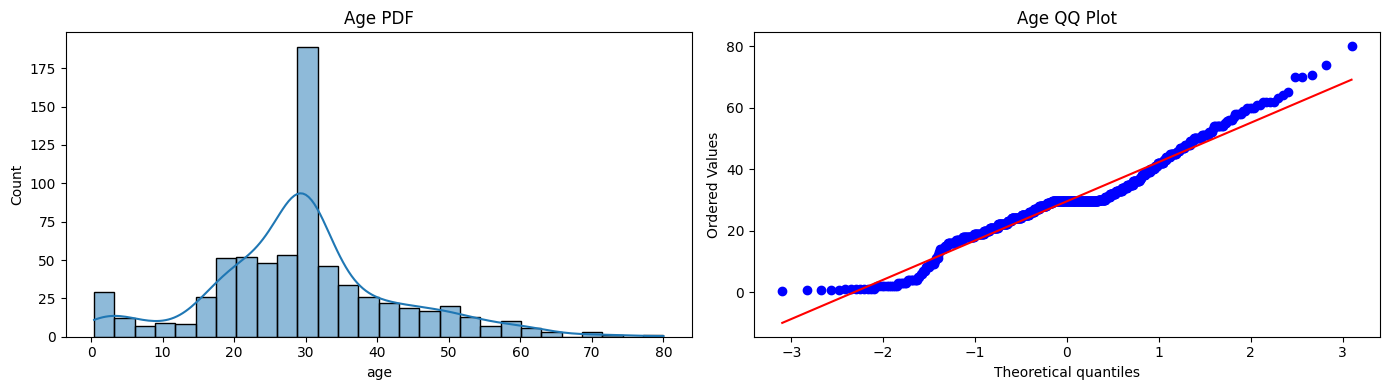

In [13]:
import scipy.stats as stats

plt.figure(figsize=(14,4))

# First Plot
plt.subplot(121)
sns.histplot(X_train['age'], kde=True)   # distplot is deprecated
plt.title("Age PDF")

# Second Plot
plt.subplot(122)
stats.probplot(X_train['age'], dist='norm', plot=plt)
plt.title("Age QQ Plot")

plt.tight_layout()
plt.show()

### visualizing the Fare feature using QQ-plot and Normal distribution

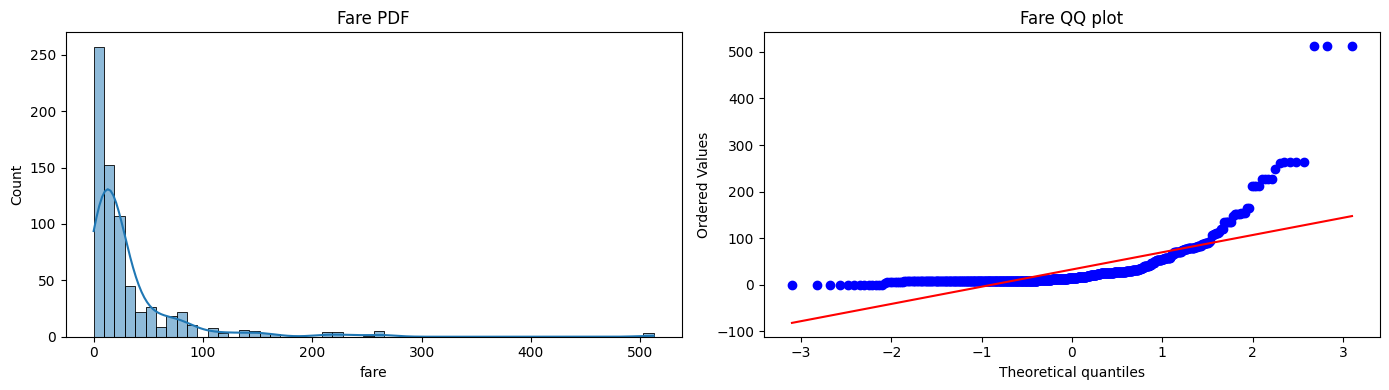

In [14]:
plt.figure(figsize=(14,4))

# first plot
plt.subplot(121)
sns.histplot(X_train['fare'],kde=True)
plt.title("Fare PDF")

# second plot
plt.subplot(122)
stats.probplot(X_train['fare'],dist='norm',plot=plt)
plt.title("Fare QQ plot")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

logr = LogisticRegression()
dtc1 = DecisionTreeClassifier()

In [16]:
logr.fit(X_train,y_train)
dtc1.fit(X_train,y_train)

y_pred1 = logr.predict(X_test)
y_pred2 = dtc1.predict(X_test)

from sklearn.metrics import accuracy_score,r2_score

print("Accuracy LogR: ",accuracy_score(y_test,y_pred1))
print("Accuracy DtC: ",accuracy_score(y_test,y_pred2))

Accuracy LogR:  0.6480446927374302
Accuracy DtC:  0.6759776536312849


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [18]:
ftr = FunctionTransformer(np.log1p)

# transforming the trained data

X_train_transformed = ftr.fit_transform(X_train)
X_test_transformed = ftr.transform(X_test)

In [20]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred3 = clf1.predict(X_test_transformed)
y_pred4 = clf2.predict(X_test_transformed)

print("Accuracy Score logR : ",accuracy_score(y_test,y_pred3))
print("Accuracy Score DtC : ",accuracy_score(y_test,y_pred4))


Accuracy Score logR :  0.6815642458100558
Accuracy Score DtC :  0.6983240223463687


### cross validation score

In [25]:
X_transformed = ftr.transform(X)

logR1 = LogisticRegression()
dtcl = DecisionTreeClassifier()

from sklearn.model_selection import cross_val_score

print("LogR :", np.mean(
    cross_val_score(logR1, X_transformed, y, scoring='accuracy', cv=10)
))

print("DecTC :", np.mean(
    cross_val_score(dtcl, X_transformed, y, scoring='accuracy', cv=10)
))

LogR : 0.678027465667915
DecTC : 0.6655805243445693


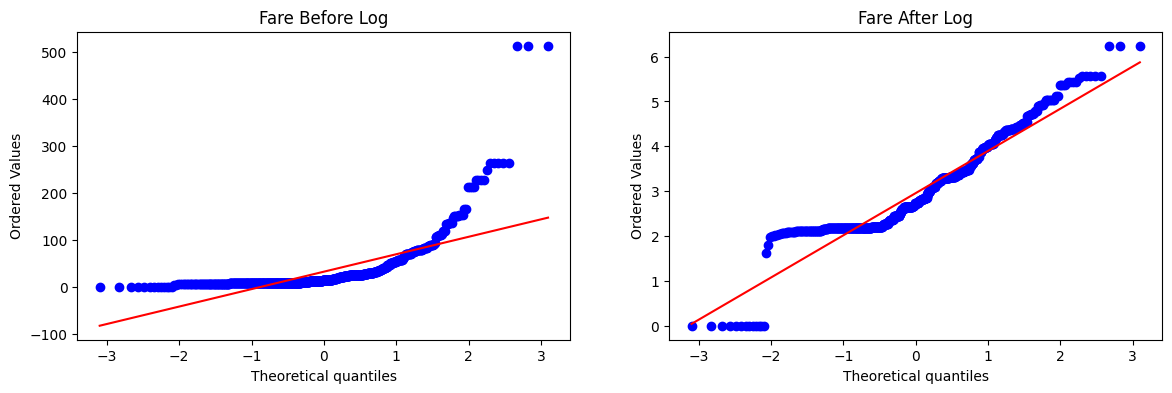

In [27]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

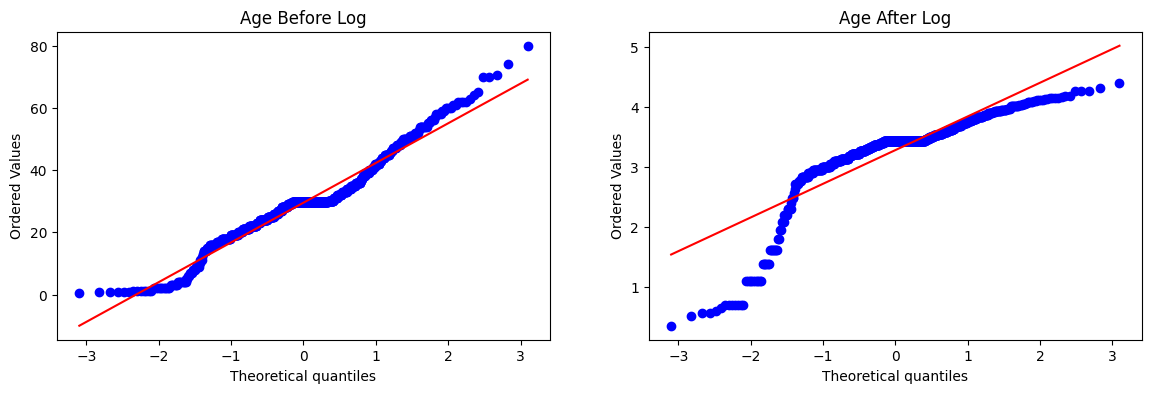

In [29]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

### here from above two fare and age plot ,we got better plot on fare but worst plot on age so we perform function transformation on fare only and keep age as it is

In [31]:
## Column Transformation

ftr1 = ColumnTransformer(
    [
        ("Log",FunctionTransformer(np.log1p),['fare'])
    ],remainder='passthrough'
)

X_train_transformed2 = ftr1.fit_transform(X_train)
X_test_transformed2 = ftr1.transform(X_test)

In [32]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6871508379888268


In [33]:
X_transformed2 = ftr1.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6599625468164793


In [34]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


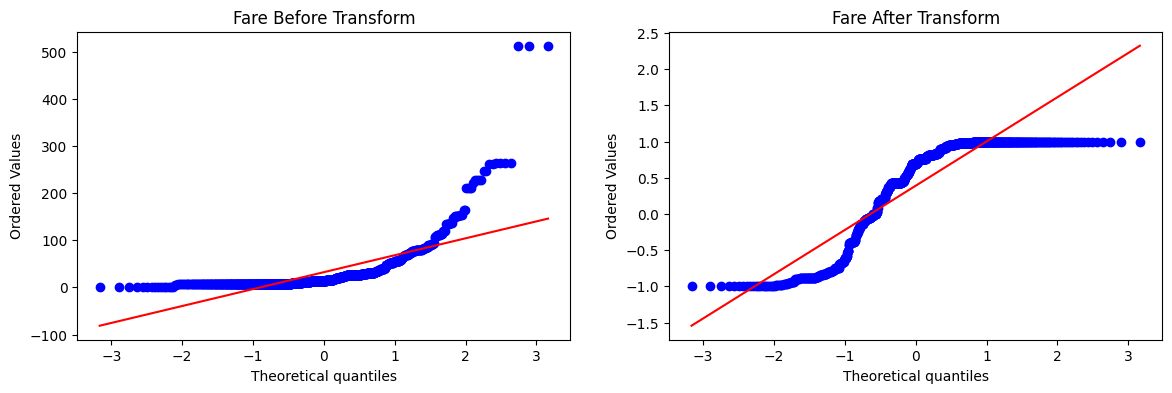

In [35]:
apply_transform(np.sin)

Accuracy 0.6431335830212235


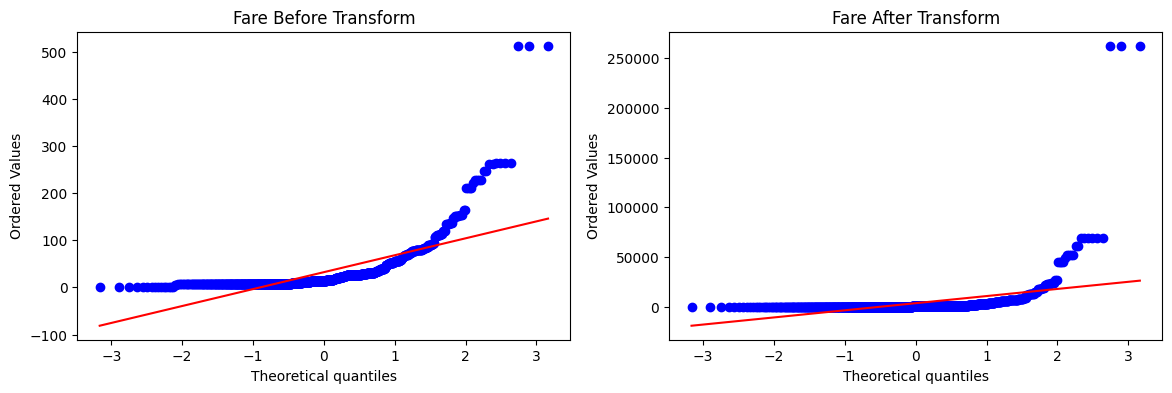

In [36]:
apply_transform(lambda x:x**2)

Accuracy 0.6589013732833957


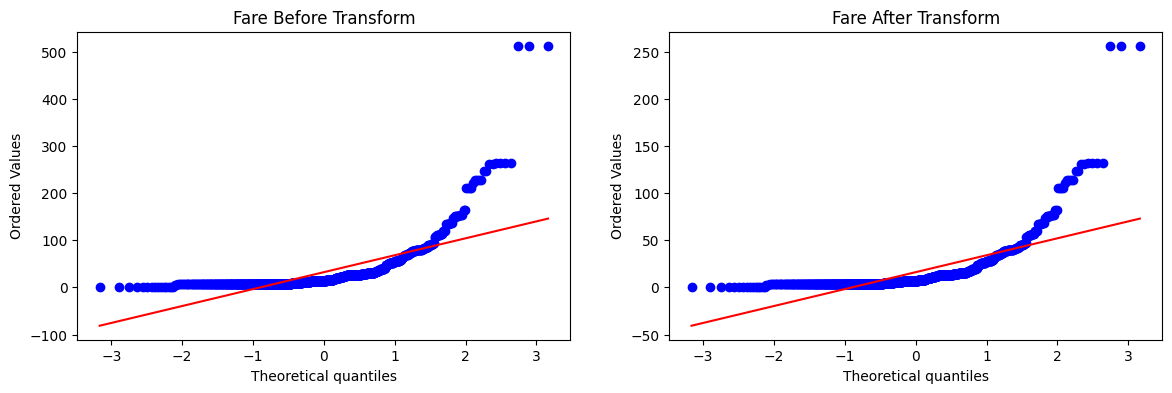

In [38]:
apply_transform(lambda x:x**1/2)

Accuracy 0.61729088639201


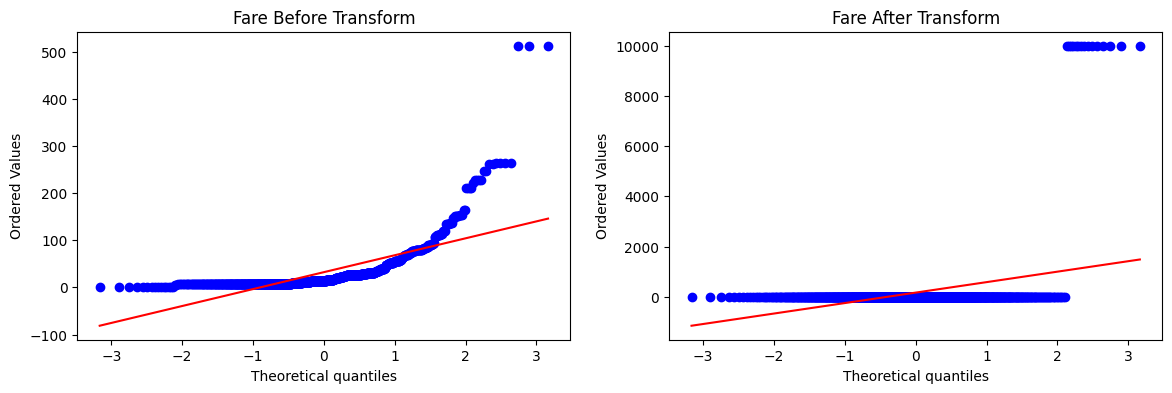

In [39]:
apply_transform(lambda x: 1/(x+0.0001))